C:\Users\PSID_PC_20\AppData\Local\Temp\ipykernel_21296\1240044367.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DFCAT["SAMPLING"] = DFCAT["SAMPLING"].str.replace("_TRAIN_RATIO0.8", "")
C:\Users\PSID_PC_20\AppData\Local\Temp\ipykernel_21296\1240044367.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  AR273["SAMPLING_SHORT"] = AR273["SAMPLING"].map(label_map)


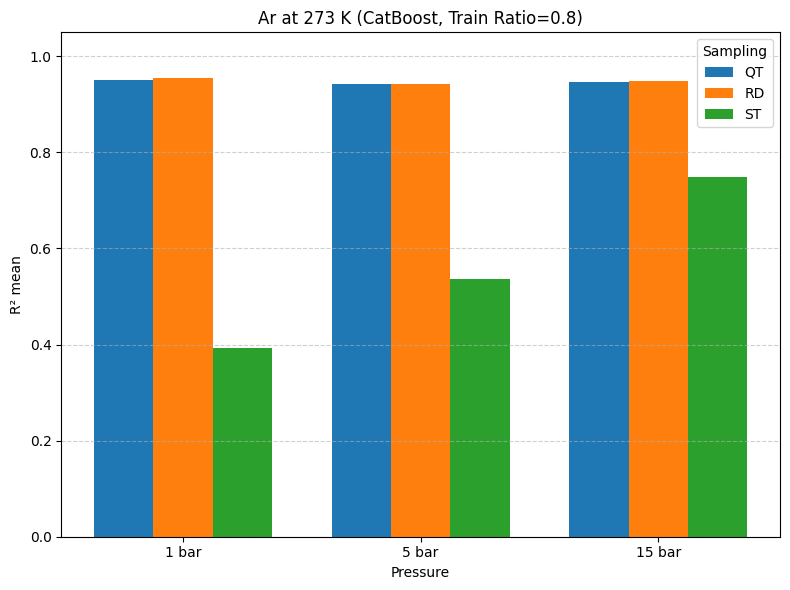

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 데이터 로드
DF = pd.read_csv("./METRICS_OUTPUT_pivot.csv")
DFCAT = DF[DF["MODEL"] == "cat"]
DFCAT["SAMPLING"] = DFCAT["SAMPLING"].str.replace("_TRAIN_RATIO0.8", "")

# Ar, 273K만 필터링
AR273 = DFCAT[(DFCAT["GAS"] == "Ar") & (DFCAT["TEMP"] == 273)]

# 샘플링 방식 매핑 (이름 짧게)
label_map = {
    "random_struct__cat": "ST",
    "random_with_input__cat": "RD",
    "qt_then_rd__cat": "QT"
}

AR273["SAMPLING_SHORT"] = AR273["SAMPLING"].map(label_map)

# 압력별 열 매핑
pressure_cols = {
    "1 bar": "R2_MEAN_HIGH_1",
    "5 bar": "R2_MEAN_HIGH_5",
    "15 bar": "R2_MEAN_HIGH_15"
}

# 플롯 준비
x = np.arange(len(pressure_cols))  # [0,1,2] → bar 위치
width = 0.25                       # 막대 너비

plt.figure(figsize=(8,6))

for i, (samp, grp) in enumerate(AR273.groupby("SAMPLING_SHORT")):
    means = [grp[col].mean() for col in pressure_cols.values()]
    plt.bar(x + i*width, means, width, label=samp)

# x축 레이블
plt.xticks(x + width, pressure_cols.keys())
plt.xlabel("Pressure")
plt.ylabel("R² mean")
plt.title("Ar at 273 K (CatBoost, Train Ratio=0.8)")
plt.legend(title="Sampling")
plt.ylim(0,1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
import argparse 
import numpy as np 
import os 
import pandas as pd 
import logging
from pathlib import Path
from tqdm import tqdm

def process_dirname(dirname):
    SPL = dirname.split("_")
    GAS = SPL[0]
    TEMP = SPL[1]
    LOW = SPL[2]
    HIGH = SPL[4]
    INPUT = SPL[6]
    SAMPLING = "_".join(SPL[8:-2])
    MODEL = SPL[-5]
    return {
        "GAS": GAS,
        "TEMP": TEMP,
        "LOW": LOW,
        "HIGH": HIGH,
        "INPUT": INPUT,
        "SAMPLING": SAMPLING,
        "MODEL": MODEL,
    }

# logging 설정
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)

S_PATH = Path("./")
N_TRIAL = 5
LIS = []

# 상위 디렉토리 순회
for P in tqdm([x for x in os.listdir(S_PATH) if os.path.isdir(S_PATH/x)], desc="Processing directories"):
    DICT = process_dirname(P)

    TRIALS = [f"trial_{i:03d}" for i in range(1, N_TRIAL + 1)]
    R2_LIS, MAE_LIS, MAPE_LIS = [], [], []

    for TRIAL in tqdm(TRIALS, desc=f"Trials for {P}", leave=False):
        T = TRIAL.replace("_", "")
        CSV = S_PATH / P / TRIAL / f"metrics_holdout_{T}.csv"
        if not CSV.exists():
            continue

        df = pd.read_csv(CSV)
        # 예시 CSV 컬럼:
        # Model,R2,MAE,RMSE,MAPE_percent,n_train,n_test,fit_time_sec,predict_time_sec

        R2 = df["R2"].values[0]
        MAE = df["MAE"].values[0]
        MAPE = df["MAPE_percent"].values[0]

        R2_LIS.append(R2)
        MAE_LIS.append(MAE)
        MAPE_LIS.append(MAPE)

    if R2_LIS:
        DICT["R2_MEAN"] = np.mean(R2_LIS)
        DICT["R2_STD"] = np.std(R2_LIS)
        DICT["MAE_MEAN"] = np.mean(MAE_LIS)
        DICT["MAE_STD"] = np.std(MAE_LIS)
        DICT["MAPE_MEAN"] = np.mean(MAPE_LIS)
        DICT["MAPE_STD"] = np.std(MAPE_LIS)
        LIS.append(DICT)

out_df = pd.DataFrame(LIS)
out_df.to_csv("METRICS_OUTPUT.csv", index=False)


Processing directories: 100%|██████████| 819/819 [00:17<00:00, 47.74it/s]


In [ ]:
df

,Model,R2,MAE,RMSE,MAPE_percent,n_train,n_test,fit_time_sec,predict_time_sec
0,cat,0.227283,0.331947,0.756362,31.434057,5684,1421,5.063227,0.003128


In [ ]:
import pandas as pd
import logging
from tqdm import tqdm

def process_metrics(input_file: str, output_file: str):
    # 로깅 설정
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[logging.StreamHandler()]
    )

    # 데이터 불러오기
    df = pd.read_csv(input_file)
    logging.info(f"Data loaded with {len(df)} rows and {len(df.columns)} columns from {input_file}")

    # 정렬 기준
    sort_cols = ["GAS", "TEMP", "MODEL", "SAMPLING", "HIGH", "LOW"]

    # 정렬 (tqdm 사용)
    for col in tqdm(sort_cols, desc="Sorting step-by-step"):
        df = df.sort_values(by=col, kind="mergesort")
        logging.info(f"Sorted by {col}")

    df_sorted = df.sort_values(by=sort_cols, ascending=True, kind="mergesort").reset_index(drop=True)
    logging.info("Final sorting completed.")

    # HIGH를 컬럼으로 pivot
    df_pivot = df_sorted.pivot(
        index=["GAS", "TEMP", "MODEL", "SAMPLING", "LOW"],
        columns="HIGH",
        values=[
            "R2_MEAN", "R2_STD",
            "MAE_MEAN", "MAE_STD",
            "MAPE_MEAN", "MAPE_STD",  # ✅ 추가
            "INPUT"
        ]
    )

    # 컬럼명 정리
    df_pivot.columns = [f"{val}_HIGH_{col}" for val, col in df_pivot.columns]
    df_pivot = df_pivot.reset_index()

    # 저장
    df_pivot.to_csv(output_file, index=False)
    logging.info(f"Saved pivoted results to {output_file}")

# 실행
process_metrics("METRICS_OUTPUT.csv", "METRICS_OUTPUT_pivot.csv")


2025-09-14 05:27:23,746 [INFO] Data loaded with 819 rows and 13 columns from METRICS_OUTPUT.csv
Sorting step-by-step:   0%|          | 0/6 [00:00<?, ?it/s]2025-09-14 05:27:23,748 [INFO] Sorted by GAS
2025-09-14 05:27:23,749 [INFO] Sorted by TEMP
2025-09-14 05:27:23,750 [INFO] Sorted by MODEL
2025-09-14 05:27:23,751 [INFO] Sorted by SAMPLING
2025-09-14 05:27:23,752 [INFO] Sorted by HIGH
2025-09-14 05:27:23,753 [INFO] Sorted by LOW
Sorting step-by-step: 100%|██████████| 6/6 [00:00<00:00, 999.95it/s]
2025-09-14 05:27:23,757 [INFO] Final sorting completed.
2025-09-14 05:27:23,772 [INFO] Saved pivoted results to METRICS_OUTPUT_pivot.csv


In [27]:
DF

,GAS,TEMP,MODEL,SAMPLING,LOW,R2_MEAN_HIGH_1,R2_MEAN_HIGH_5,R2_MEAN_HIGH_15,R2_STD_HIGH_1,R2_STD_HIGH_5,R2_STD_HIGH_15,MAE_MEAN_HIGH_1,MAE_MEAN_HIGH_5,MAE_MEAN_HIGH_15,MAE_STD_HIGH_1,MAE_STD_HIGH_5,MAE_STD_HIGH_15,INPUT_HIGH_1,INPUT_HIGH_5,INPUT_HIGH_15
0,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.980530,0.942551,0.942233,0.001539,0.002202,0.003102,0.019842,0.118815,0.265060,0.000491,0.002239,0.002964,struct+input,struct+input,struct+input
1,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.981844,0.946434,0.947935,0.000772,0.002550,0.002759,0.017917,0.115891,0.261473,0.000514,0.001920,0.005185,struct+input,struct+input,struct+input
2,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.10,0.986484,0.950708,0.948975,0.002860,0.002741,0.004040,0.016646,0.111387,0.256945,0.000469,0.003044,0.006056,struct+input,struct+input,struct+input
3,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.50,0.995210,0.958574,0.949225,0.000432,0.003612,0.003554,0.011522,0.101623,0.251327,0.000202,0.001922,0.006417,struct+input,struct+input,struct+input
4,Ar,273,cat,random_struct__cat_TRAIN_RATIO0.8,0.01,0.392270,0.536265,0.748705,0.033201,0.029918,0.018831,0.212008,0.466602,0.621910,0.006755,0.017882,0.024048,struct,struct,struct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,N2,293,cat,random_struct__cat_TRAIN_RATIO0.8,0.01,NaN,0.375316,NaN,NaN,0.045065,NaN,NaN,0.325361,NaN,NaN,0.003643,NaN,NaN,struct,NaN
221,N2,293,cat,random_with_input__cat_TRAIN_RATIO0.8,0.01,NaN,0.779396,NaN,NaN,0.084503,NaN,NaN,0.077521,NaN,NaN,0.005835,NaN,NaN,struct+input,NaN
222,O2,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,NaN,0.970534,NaN,NaN,0.003469,NaN,NaN,0.055283,NaN,NaN,0.001283,NaN,NaN,struct+input,NaN
223,O2,293,cat,random_struct__cat_TRAIN_RATIO0.8,0.01,NaN,0.384544,NaN,NaN,0.085843,NaN,NaN,0.321031,NaN,NaN,0.007053,NaN,NaN,struct,NaN
